In [1]:
import os 

len(os.listdir('/home/u171/mth_pub/order_data')) / 2

26.0

In [4]:
# ==================== 文件1: 数据处理和存储 ====================
import numpy as np 
import pandas as pd 
import os 

pd.options.mode.chained_assignment = None 

# 配置路径 
root_path = '/home/u171/mth_pub/order_data' 
outputpath = '/home/u171/mth_pub/matched_orders' 
os.makedirs(outputpath, exist_ok=True) 

# 币种列表
symbols = sorted([
    "AAVEUSDT", "ADAUSDT", "ARBUSDT", "ATOMUSDT", "AVAXUSDT", 
    "BCHUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "DOTUSDT", 
    "ETCUSDT", "ETHUSDT", "FILUSDT", "HBARUSDT", "LINKUSDT", 
    "LTCUSDT", "SOLUSDT", "TONUSDT", "TRXUSDT", "WLDUSDT", 
    "XLMUSDT", "XRPUSDT"
    
])

mstr = "1m"
fee = 0.0001 

for symbol in symbols:
    output_file = os.path.join(outputpath, f"{symbol}_{mstr}.h5")
    
    order_file_path = os.path.join(root_path, f"{symbol}_orders.csv")
    
    if not os.path.exists(order_file_path):
        print(f"文件不存在: {order_file_path},跳过")
        continue
    
    print(f"处理 {symbol}, 读取文件: {order_file_path}")
    
    try:
        ns = pd.read_csv(order_file_path, header=None) 
        ns.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen", "fkey", "bid1", "ask1"]
        ns.sort_values('uts', inplace=True)
        
    except (pd.errors.EmptyDataError, FileNotFoundError) as e:
        print(f"警告: 文件 {order_file_path} 读取失败: {e}, 跳过")
        continue
    
    if len(ns) == 0:
        print(f"警告: {symbol} 数据为空,跳过")
        continue
    
    # 时间戳转换 
    ns["cts"] = (ns["cts"] / 1000).astype("int") 
    ns["uts"] = (ns["uts"] / 1000).astype("int") 
    
    # 开仓订单处理
    ns_open = ns[(ns["oid"].str.startswith("o")) & (ns["sid"] == 0)] 
    
    if len(ns_open) == 0:
        print(f"警告: {symbol} 没有开仓订单,跳过") 
        continue 
    
    ns_open["holding"] = ns_open['uts'] - ns_open['cts'] 
    print(f'开仓持有时间均值: {ns_open["holding"].mean():.2f}秒') 
    
    ns_open["range"] = (ns_open["oid"].str.split("_", expand=True)[2].astype("float") * 10000).round(0)
    ranges = ns_open["range"].drop_duplicates().tolist() 
    print(f'Range列表: {ranges}') 
    
    prices = ns_open.groupby("oid").last().reset_index()[
        ["cts", "uts", 'holding', "oid", "price", "fkey", "side", "range", 'tlen', 'inpos']
    ]
    prices["open_uts"] = prices["uts"]
    prices["tlen"] = prices["tlen"] * prices["price"] 
    
    famount = ns_open.groupby("oid")["famount"].sum().reset_index() 
    ns_open_m = pd.merge(prices, famount, on=["oid"], how="left") 
    
    # 平仓订单处理
    ns_close = ns[(ns["oid"].str.startswith("c")) & (ns["sid"] == 1)].sort_values('uts')
    
    if len(ns_close) == 0:
        print(f"警告: {symbol} 没有平仓订单,跳过")
        continue
    
    ns_close["fkey"] = ns_close["fkey"].str.split("_", expand=True)[2]
    ns_close["crange"] = (ns_close["oid"].str.split("_", expand=True)[5].astype("float") * 10000).round(0)
    
    fts = ns_close.groupby("fkey")[["uts", "crange"]].last().reset_index()
    count = ns_close.groupby("fkey")[["uts"]].count().reset_index()
    count.columns = ["fkey", "close_count"]
    fts = pd.merge(fts, count, left_on='fkey', right_on='fkey', how='inner')
    fts["uts"] = fts["uts"].astype("int") 
    fts.columns = ["fkey", "fts", "crange", "close_count"] 
    
    famounts = ns_close.groupby("fkey")["famount"].sum().reset_index()
    famounts.columns = ["fkey", "camount"]
    
    ns_close["pa"] = ns_close["famount"] * ns_close["price"]
    pas = ns_close.groupby("fkey")["pa"].sum().reset_index()
    pas = pd.merge(pas, fts, on=["fkey"], how="left")
    nm = pd.merge(pas, famounts, on=["fkey"], how="left")
    nm["cprice"] = nm["pa"] / nm["camount"]
    
    # 合并开仓和平仓数据
    nms = pd.merge(ns_open_m, nm, on="fkey", how="left").dropna()
    
    if len(nms) == 0:
        print(f"警告: {symbol} 匹配后数据为空,跳过")
        continue
    
    # 计算PnL
    nms.loc[nms["side"] == "buy", "pnlu"] = (
        (nms[nms["side"] == "buy"]["cprice"] - nms[nms["side"] == "buy"]["price"]) / 
        nms[nms["side"] == "buy"]["price"]
    )
    nms.loc[nms["side"] == "sell", "pnlu"] = (
        (nms[nms["side"] == "sell"]["price"] - nms[nms["side"] == "sell"]["cprice"]) / 
        nms[nms["side"] == "sell"]["price"]
    )
    nms["pnlu_wfee"] = nms["pnlu"] - 2 * fee
    
    nms["fts"] = nms["fts"].astype("int")
    nms["holding_close"] = nms['fts'] - nms['open_uts']
    
    print(f'平仓持有时间均值: {nms["holding_close"].mean():.2f}秒')
    print(f'平均PnL: {nms["pnlu"].mean():.6f}')
    
    # 整理输出列 
    nms = nms[[
        'cts', 'open_uts', 'fts', 'holding', 'holding_close', 'close_count',
        'price', 'cprice', 'camount', 'side', 'range', 'crange', 'tlen', 'inpos',
        'pnlu', 'pnlu_wfee'
    ]] 
    nms.sort_values('cts', inplace=True) 
    
    print(f"\n总记录数: {len(nms)}, 总体平均PnL: {nms.pnlu.mean():.6f}") 
    
    # 保存结果 
    nms.to_hdf(output_file, key="df", mode='w') 
    print(f"数据已保存: {output_file}\n") 
    print("=" * 80) 

print("\n所有数据处理完成!") 

处理 AAVEUSDT, 读取文件: /home/u171/mth_pub/order_data/AAVEUSDT_orders.csv
开仓持有时间均值: 53.89秒
Range列表: [4.0, 6.0, 8.0, 15.0, 2.0, 10.0, 20.0]
平仓持有时间均值: 107.32秒
平均PnL: -0.000375

总记录数: 254907, 总体平均PnL: -0.000375
数据已保存: /home/u171/mth_pub/matched_orders/AAVEUSDT_1m.h5

处理 ADAUSDT, 读取文件: /home/u171/mth_pub/order_data/ADAUSDT_orders.csv
开仓持有时间均值: 58.57秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 284.89秒
平均PnL: -0.000220

总记录数: 224686, 总体平均PnL: -0.000220
数据已保存: /home/u171/mth_pub/matched_orders/ADAUSDT_1m.h5

处理 ARBUSDT, 读取文件: /home/u171/mth_pub/order_data/ARBUSDT_orders.csv
开仓持有时间均值: 68.11秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 409.81秒
平均PnL: -0.000158

总记录数: 176421, 总体平均PnL: -0.000158
数据已保存: /home/u171/mth_pub/matched_orders/ARBUSDT_1m.h5

处理 ATOMUSDT, 读取文件: /home/u171/mth_pub/order_data/ATOMUSDT_orders.csv
开仓持有时间均值: 58.42秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 116.12秒
平均PnL: -0.000347

总记录数: 292510, 总体平均PnL: -0.000347
数据已保存: /home/u171/mth_p

读取 AAVEUSDT...
AAVEUSDT - 平均PnL: -0.000375, 胜率: 42.18%
读取 ADAUSDT...
ADAUSDT - 平均PnL: -0.000220, 胜率: 52.00%
读取 ARBUSDT...
ARBUSDT - 平均PnL: -0.000158, 胜率: 50.48%
读取 ATOMUSDT...
ATOMUSDT - 平均PnL: -0.000347, 胜率: 44.66%
读取 AVAXUSDT...
AVAXUSDT - 平均PnL: -0.000272, 胜率: 48.39%
读取 BCHUSDT...
BCHUSDT - 平均PnL: -0.000248, 胜率: 49.71%
读取 BNBUSDT...
BNBUSDT - 平均PnL: -0.000252, 胜率: 42.57%
读取 BTCUSDT...
BTCUSDT - 平均PnL: -0.000213, 胜率: 50.06%
读取 DOGEUSDT...
DOGEUSDT - 平均PnL: -0.000270, 胜率: 50.29%
读取 DOTUSDT...
DOTUSDT - 平均PnL: -0.000012, 胜率: 53.06%
读取 ETCUSDT...
ETCUSDT - 平均PnL: -0.000159, 胜率: 49.84%
读取 ETHUSDT...
ETHUSDT - 平均PnL: -0.000202, 胜率: 52.42%
读取 FILUSDT...
FILUSDT - 平均PnL: 0.000071, 胜率: 55.90%
读取 HBARUSDT...
HBARUSDT - 平均PnL: -0.000370, 胜率: 40.25%
读取 LINKUSDT...
LINKUSDT - 平均PnL: -0.000267, 胜率: 45.98%
读取 LTCUSDT...
LTCUSDT - 平均PnL: -0.000250, 胜率: 51.08%
读取 SOLUSDT...
SOLUSDT - 平均PnL: -0.000287, 胜率: 50.80%
读取 TONUSDT...
TONUSDT - 平均PnL: -0.000185, 胜率: 48.78%
读取 TRXUSDT...
TRXUSDT - 平均PnL: -0.0

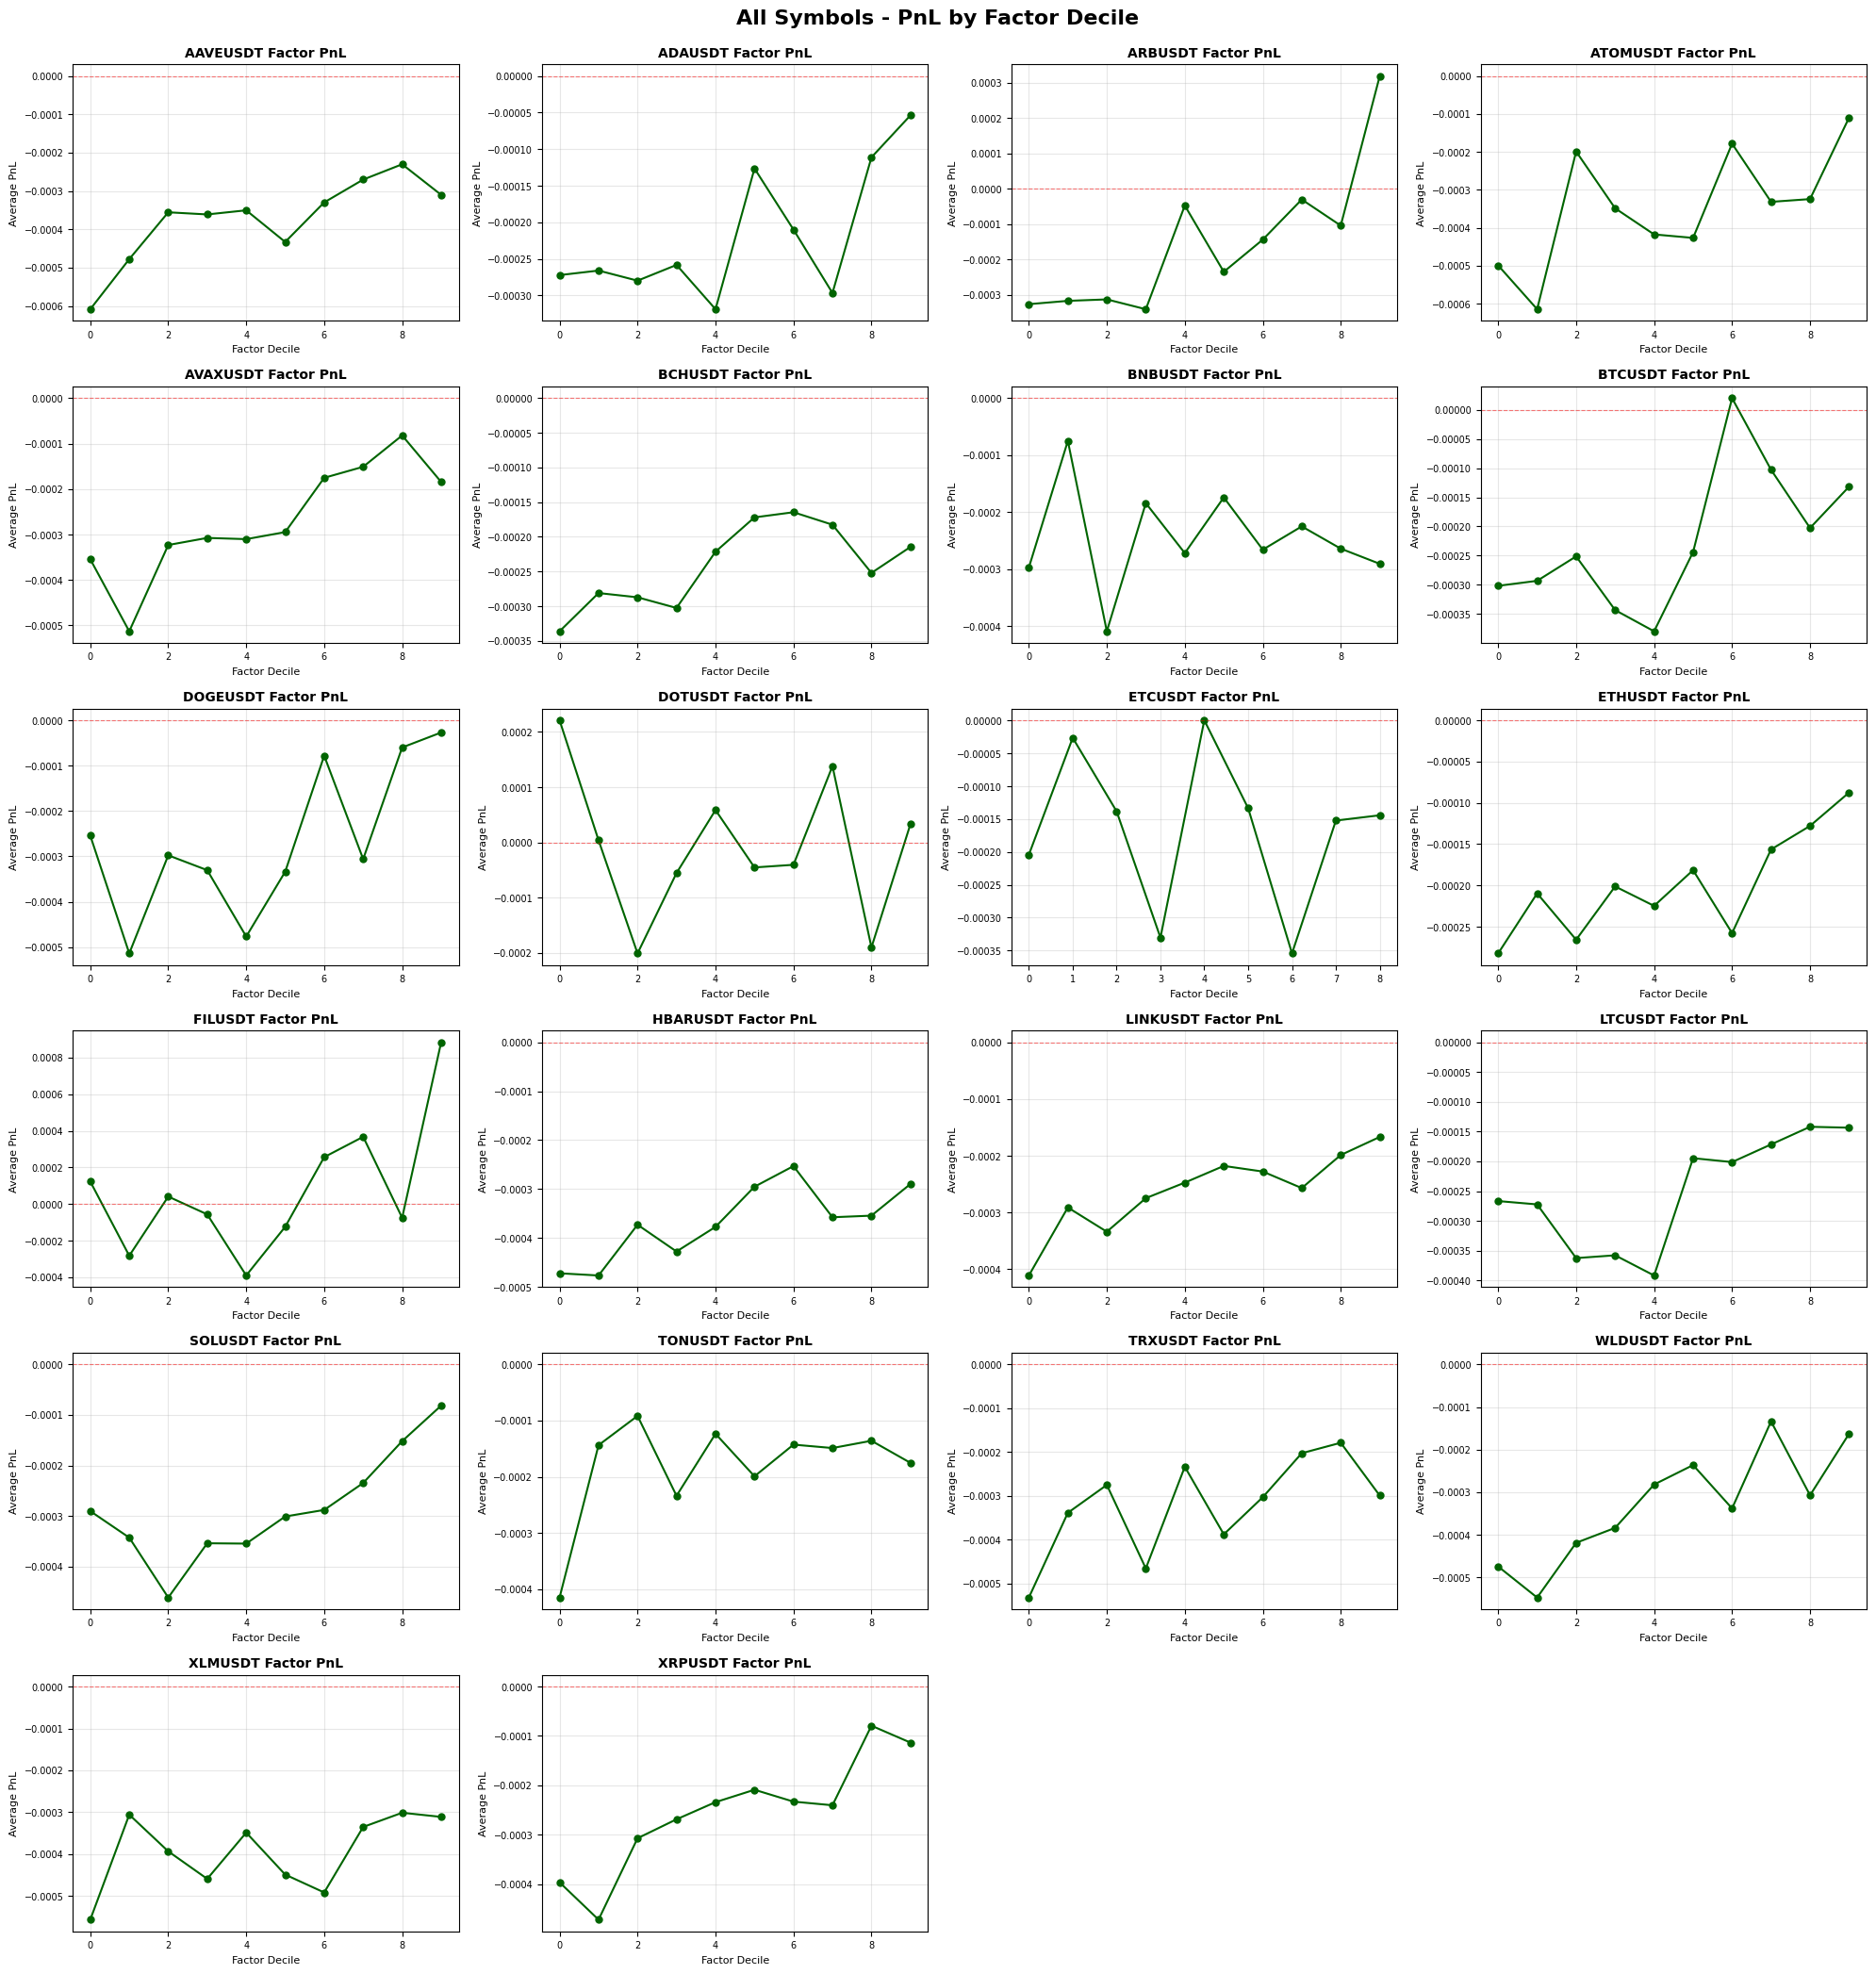

图2已保存: all_symbols_factor_pnl.png

所有图表已保存至: /home/u171/mth_pub/figures
分析完成!


In [5]:
# ==================== 文件2: 数据读取和分析作图 ====================
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt 

pd.options.mode.chained_assignment = None 

# 配置路径 
outputpath = '/home/u171/mth_pub/matched_orders' 
figpath = '/home/u171/mth_pub/figures' 
os.makedirs(figpath, exist_ok=True) 

# 币种列表
symbols = sorted([
    "AAVEUSDT", "ADAUSDT", "ARBUSDT", "ATOMUSDT", "AVAXUSDT", 
    "BCHUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "DOTUSDT", 
    "ETCUSDT", "ETHUSDT", "FILUSDT", "HBARUSDT", "LINKUSDT", 
    "LTCUSDT", "SOLUSDT", "TONUSDT", "TRXUSDT", "WLDUSDT", 
    "XLMUSDT", "XRPUSDT"
])

mstr = "1m"

# 存储所有标的的数据
all_data = {}

# 读取所有数据
for symbol in symbols:
    input_file = os.path.join(outputpath, f"{symbol}_{mstr}.h5")
    
    if not os.path.exists(input_file):
        print(f"文件不存在: {input_file},跳过")
        continue
    
    print(f"读取 {symbol}...")
    
    try:
        nms = pd.read_hdf(input_file, key="df")
        
        if len(nms) == 0:
            print(f"警告: {symbol} 数据为空,跳过")
            continue
        
        # 准备数据
        order_df = nms.rename(columns={'cts': 'ts'}).set_index('ts')[
            ['pnlu', 'pnlu_wfee', 'tlen', 'inpos', 'holding', 'holding_close', 'range', 'crange', 'side']
        ]
        
        # 计算因子
        factor_df2 = (order_df.groupby('ts')[['pnlu']].count() * order_df.groupby('ts')[['pnlu']].mean())
        ts_df = pd.DataFrame({'ts': list(range(factor_df2.index.min(), factor_df2.index.max()+1, 5))}).set_index('ts')
        factor_df2 = pd.merge(ts_df, factor_df2, left_index=True, right_index=True, how='left')
        factor_df2['ylabel'] = factor_df2['pnlu'].rolling(720, min_periods=300).mean().shift(120)
        factor_df2 = factor_df2[['ylabel']].ffill()
        
        # 合并因子
        final_df1 = pd.merge(order_df, factor_df2, left_index=True, right_index=True, how='left')
        
        all_data[symbol] = {
            'order_df': order_df,
            'final_df': final_df1,
            'avg_pnl': nms['pnlu'].mean(),
            'win_rate': (nms['pnlu'] > 0).sum() / len(nms)
        }
        
        print(f"{symbol} - 平均PnL: {all_data[symbol]['avg_pnl']:.6f}, 胜率: {all_data[symbol]['win_rate']:.2%}")
        
    except Exception as e:
        print(f"读取失败: {e}")
        continue

print(f"\n成功读取 {len(all_data)} 个标的数据")

# ========== 图1: 所有标的累积收益曲线（子图） ==========
n_symbols = len(all_data)
n_cols = 4
n_rows = (n_symbols + n_cols - 1) // n_cols

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
# axes = axes.flatten()

# for idx, (symbol, data) in enumerate(all_data.items()):
#     ax = axes[idx]
#     data['order_df']['pnlu_wfee'].cumsum().plot(ax=ax, linewidth=1.2, color='steelblue')
#     ax.set_title(f'{symbol} Cumulative PnL\nAvg: {data["avg_pnl"]:.4f} | WinRate: {data["win_rate"]:.1%}', 
#                  fontsize=10, fontweight='bold')
#     ax.set_xlabel('Timestamp', fontsize=8)
#     ax.set_ylabel('Cumulative PnL', fontsize=8)
#     ax.grid(alpha=0.3)
#     ax.tick_params(labelsize=7)

# # 隐藏多余的子图
# for idx in range(n_symbols, len(axes)):
#     axes[idx].axis('off')

# plt.suptitle('All Symbols - Cumulative PnL', fontsize=16, fontweight='bold', y=0.995)
# plt.tight_layout()
# # plt.savefig(os.path.join(figpath, "all_symbols_cumulative_pnl.png"), dpi=150, bbox_inches='tight')
# plt.show()

# print(f"图1已保存: all_symbols_cumulative_pnl.png")

# ========== 图2: 所有标的因子分组PnL（子图） ==========
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten() 

for idx, (symbol, data) in enumerate(all_data.items()):
    ax = axes[idx]

    # tlen, ylabel
    try:
        grouped_pnl = data['final_df'].groupby(
            pd.qcut(data['final_df']['ylabel'], 10, labels=False, duplicates='drop')
        )['pnlu'].mean()
        
        ax.plot(grouped_pnl.index, grouped_pnl.values, marker='o', linewidth=1.5, 
                markersize=5, color='darkgreen')
        ax.set_title(f'{symbol} Factor PnL', fontsize=10, fontweight='bold')
        ax.set_xlabel('Factor Decile', fontsize=8)
        ax.set_ylabel('Average PnL', fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{symbol} - Error', fontsize=10)

# 隐藏多余的子图
for idx in range(n_symbols, len(axes)):
    axes[idx].axis('off')

plt.suptitle('All Symbols - PnL by Factor Decile', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(figpath, "all_symbols_factor_pnl.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"图2已保存: all_symbols_factor_pnl.png")
print(f"\n所有图表已保存至: {figpath}")
print("分析完成!")


处理 AAVEUSDT, 读取文件: /home/u171/mth_pub/order_data/AAVEUSDT_orders.csv
开仓持有时间均值: 54.24秒
Range列表: [4.0, 6.0, 8.0, 15.0, 2.0, 10.0, 20.0]
平仓持有时间均值: 110.02秒
平均PnL: -0.000385

总记录数: 224714, 总体平均PnL: -0.000385


count    224714.000000
mean        165.893086
std         144.293715
min           5.000000
25%          76.000000
50%         128.000000
75%         203.000000
max        2198.000000
dtype: float64

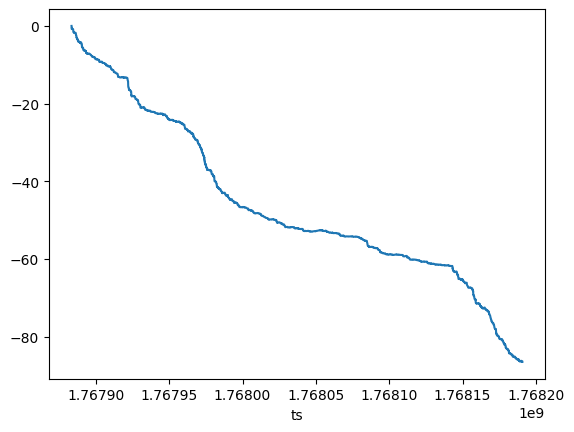

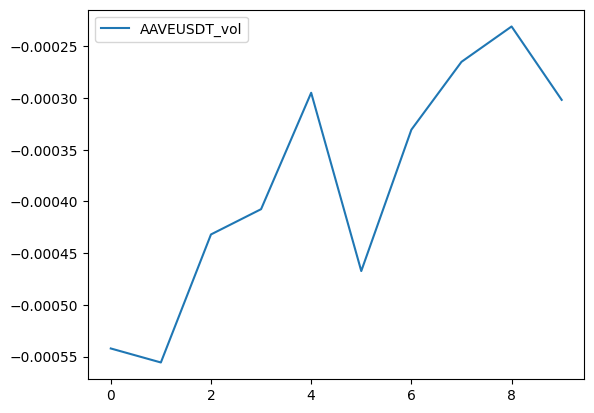

处理 ADAUSDT, 读取文件: /home/u171/mth_pub/order_data/ADAUSDT_orders.csv
开仓持有时间均值: 58.50秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 299.78秒
平均PnL: -0.000240

总记录数: 198958, 总体平均PnL: -0.000240


count    198958.000000
mean        356.788920
std         535.009888
min           5.000000
25%          99.000000
50%         175.000000
75%         374.000000
max        6084.000000
dtype: float64

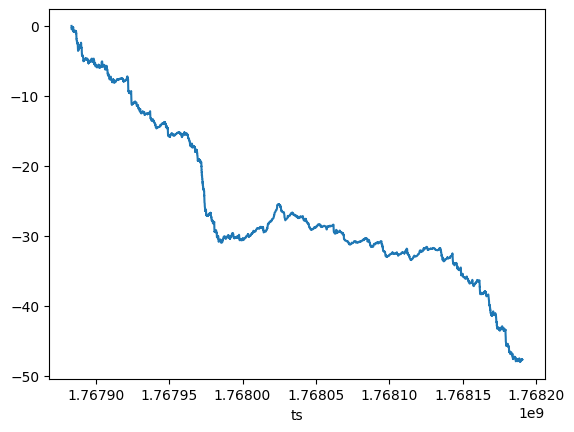

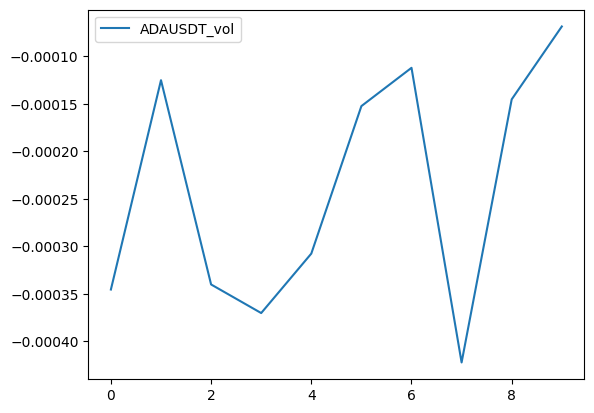

处理 ARBUSDT, 读取文件: /home/u171/mth_pub/order_data/ARBUSDT_orders.csv
开仓持有时间均值: 67.91秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 417.26秒
平均PnL: -0.000204

总记录数: 155821, 总体平均PnL: -0.000204


count    155821.000000
mean        481.075227
std         775.950633
min           5.000000
25%         112.000000
50%         208.000000
75%         515.000000
max       10771.000000
dtype: float64

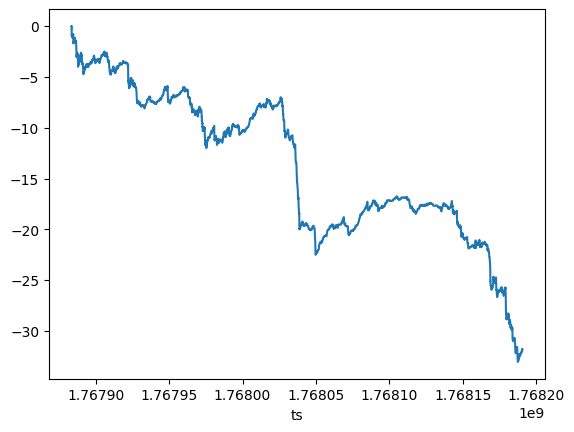

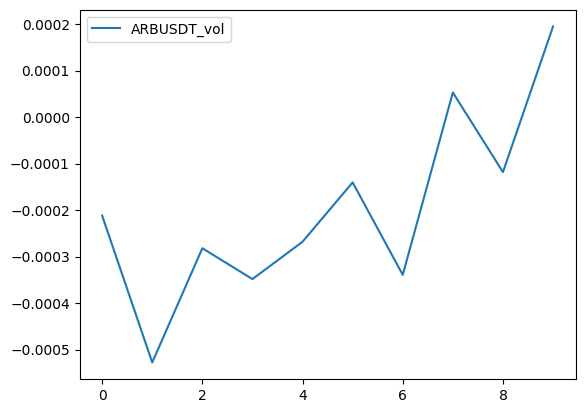

处理 ATOMUSDT, 读取文件: /home/u171/mth_pub/order_data/ATOMUSDT_orders.csv
开仓持有时间均值: 58.22秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 116.99秒
平均PnL: -0.000361

总记录数: 262706, 总体平均PnL: -0.000361


count    262706.000000
mean        175.711708
std         166.625562
min           5.000000
25%          79.000000
50%         129.000000
75%         208.000000
max        2253.000000
dtype: float64

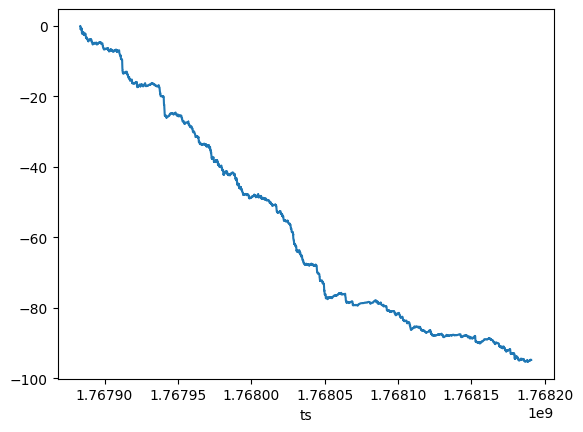

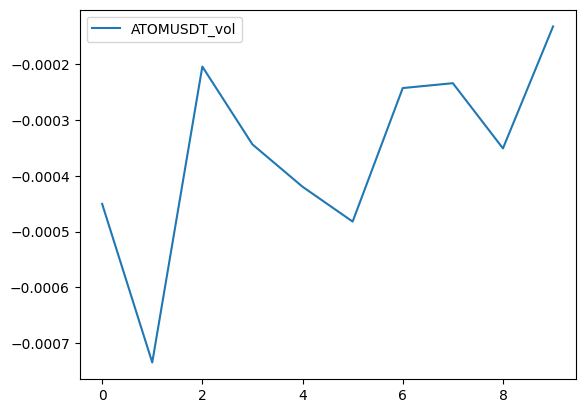

处理 AVAXUSDT, 读取文件: /home/u171/mth_pub/order_data/AVAXUSDT_orders.csv
开仓持有时间均值: 55.46秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 143.59秒
平均PnL: -0.000280

总记录数: 207807, 总体平均PnL: -0.000280


count    207807.000000
mean        199.095050
std         191.401198
min           5.000000
25%          83.000000
50%         140.000000
75%         243.000000
max        2271.000000
dtype: float64

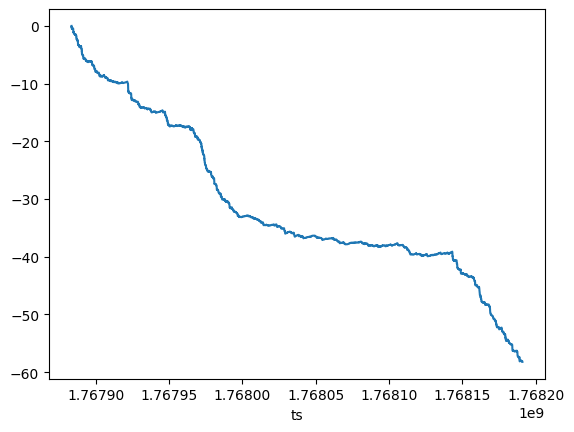

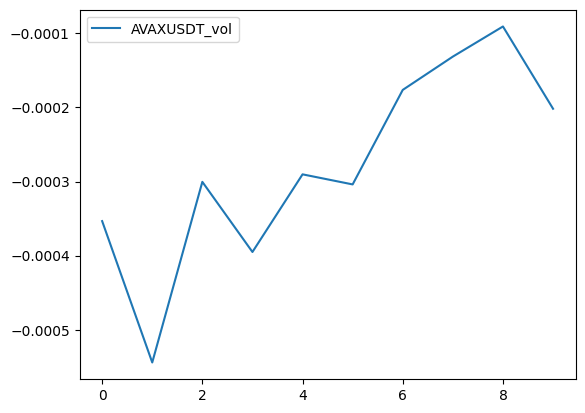

处理 BCHUSDT, 读取文件: /home/u171/mth_pub/order_data/BCHUSDT_orders.csv
开仓持有时间均值: 60.48秒
Range列表: [2.0, 4.0, 6.0, 8.0, 15.0, 10.0, 20.0]
平仓持有时间均值: 103.29秒
平均PnL: -0.000242

总记录数: 178548, 总体平均PnL: -0.000242


count    178548.000000
mean        162.672295
std         132.651226
min           5.000000
25%          80.000000
50%         127.000000
75%         201.000000
max        1678.000000
dtype: float64

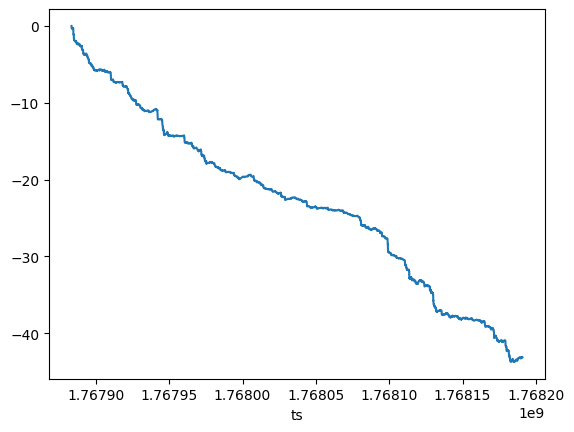

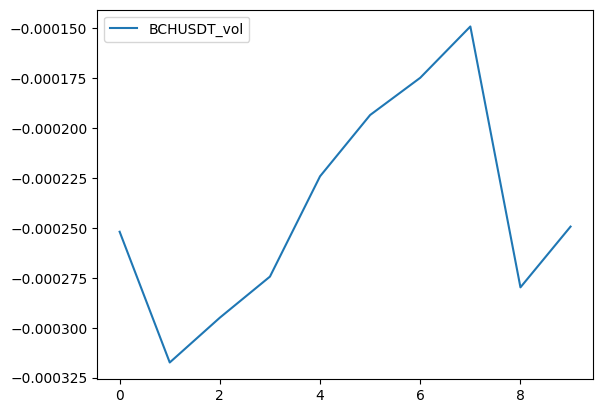

处理 BNBUSDT, 读取文件: /home/u171/mth_pub/order_data/BNBUSDT_orders.csv
开仓持有时间均值: 63.43秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 270.87秒
平均PnL: -0.000265

总记录数: 105799, 总体平均PnL: -0.000265


count    105799.000000
mean        334.401289
std         369.073145
min           5.000000
25%         119.000000
50%         206.000000
75%         410.000000
max        4296.000000
dtype: float64

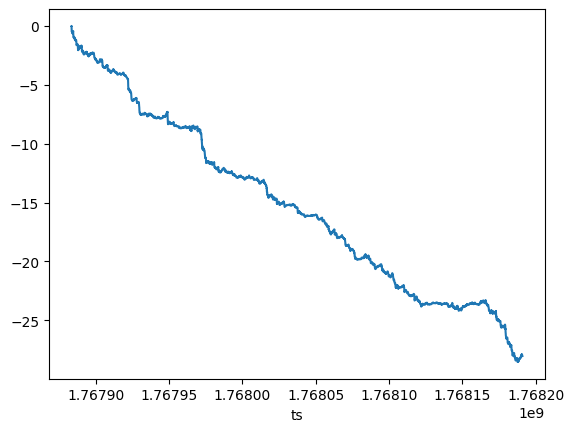

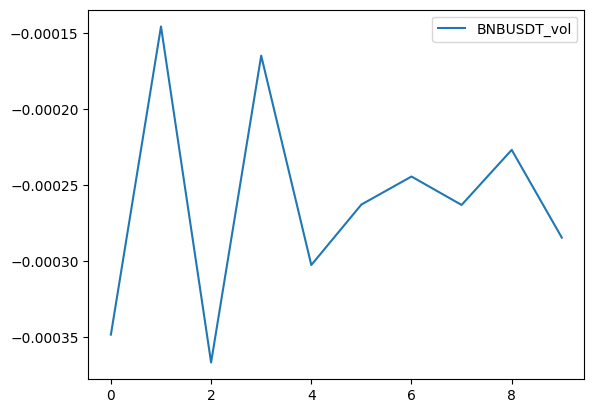

处理 BTCUSDT, 读取文件: /home/u171/mth_pub/order_data/BTCUSDT_orders.csv
开仓持有时间均值: 52.83秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 619.93秒
平均PnL: -0.000219

总记录数: 60647, 总体平均PnL: -0.000219


count    60647.000000
mean       672.849523
std       1606.705729
min          5.000000
25%         90.000000
50%        169.000000
75%        437.000000
max      16401.000000
dtype: float64

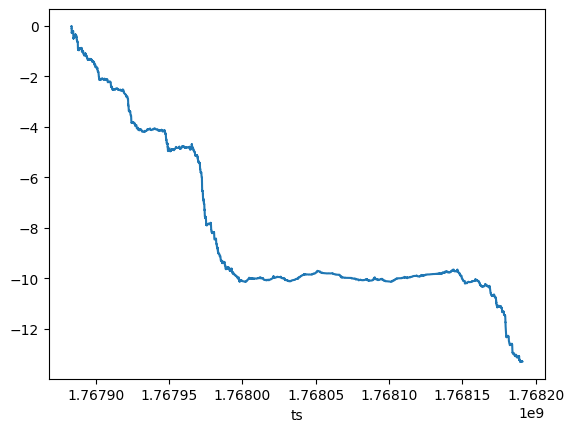

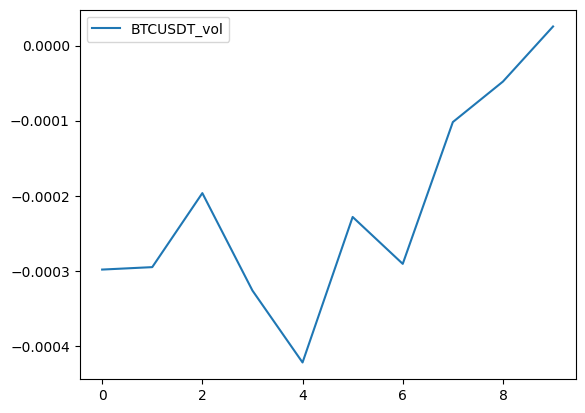

处理 DOGEUSDT, 读取文件: /home/u171/mth_pub/order_data/DOGEUSDT_orders.csv
开仓持有时间均值: 54.25秒
Range列表: [2.0, 4.0, 6.0, 10.0, 8.0, 15.0, 20.0]
平仓持有时间均值: 175.63秒
平均PnL: -0.000277

总记录数: 188291, 总体平均PnL: -0.000277


count    188291.000000
mean        228.454578
std         268.825468
min           5.000000
25%          82.000000
50%         143.000000
75%         263.000000
max        3337.000000
dtype: float64

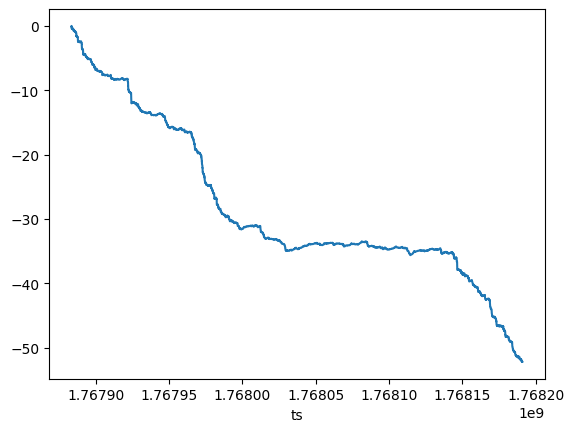

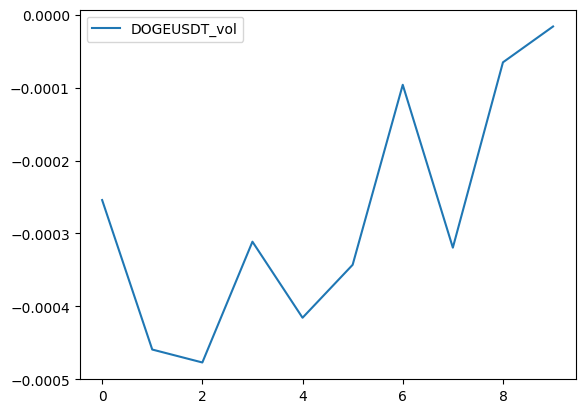

处理 DOTUSDT, 读取文件: /home/u171/mth_pub/order_data/DOTUSDT_orders.csv
开仓持有时间均值: 63.84秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 269.27秒
平均PnL: -0.000042

总记录数: 172890, 总体平均PnL: -0.000042


count    172890.000000
mean        330.370322
std         459.934757
min           5.000000
25%          97.000000
50%         170.000000
75%         376.000000
max        7246.000000
dtype: float64

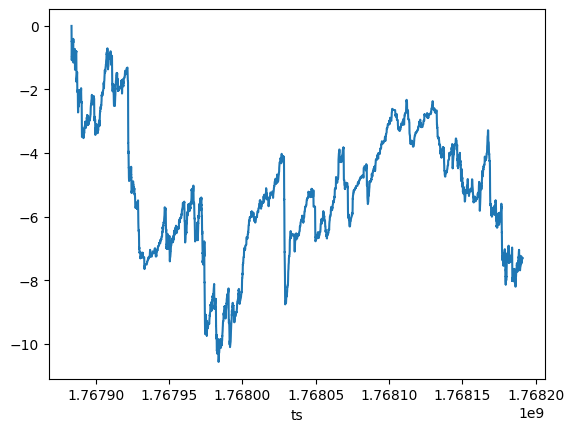

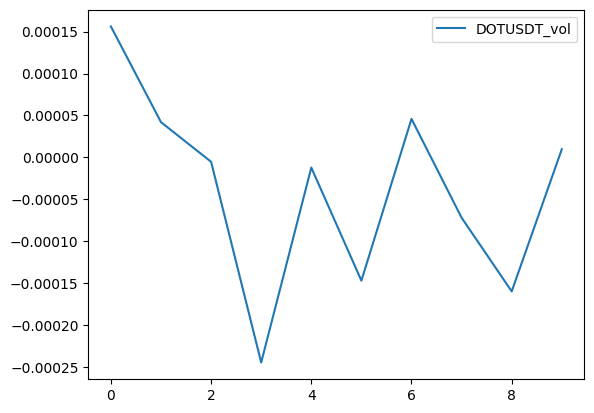

处理 ETCUSDT, 读取文件: /home/u171/mth_pub/order_data/ETCUSDT_orders.csv
开仓持有时间均值: 68.43秒
Range列表: [2.0, 4.0, 6.0, 20.0, 8.0, 10.0, 15.0]
平仓持有时间均值: 84.24秒
平均PnL: -0.000178

总记录数: 92813, 总体平均PnL: -0.000178


count    92813.000000
mean       152.739756
std        134.853881
min          5.000000
25%         79.000000
50%        119.000000
75%        172.000000
max       1656.000000
dtype: float64

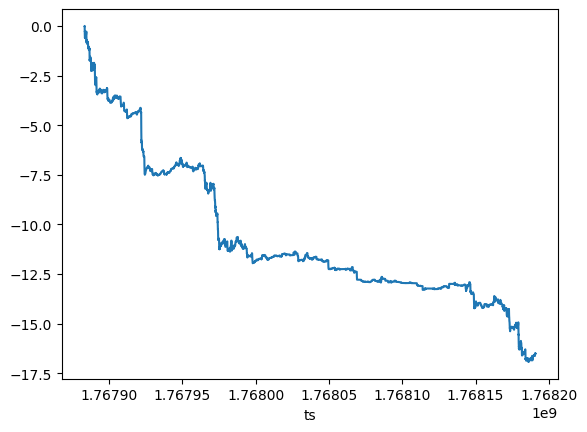

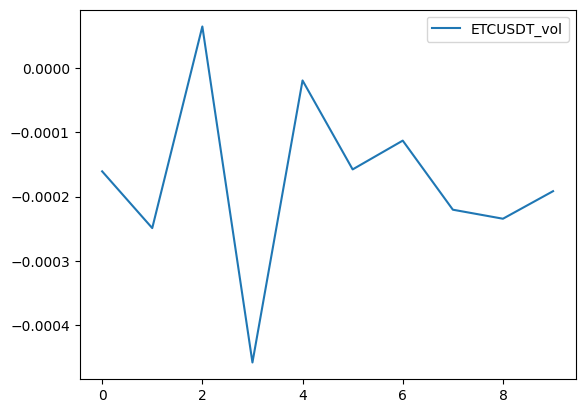

处理 ETHUSDT, 读取文件: /home/u171/mth_pub/order_data/ETHUSDT_orders.csv
开仓持有时间均值: 50.79秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 304.53秒
平均PnL: -0.000209

总记录数: 96597, 总体平均PnL: -0.000209


count    96597.000000
mean       354.904272
std        662.585998
min          5.000000
25%         76.000000
50%        141.000000
75%        305.000000
max       8705.000000
dtype: float64

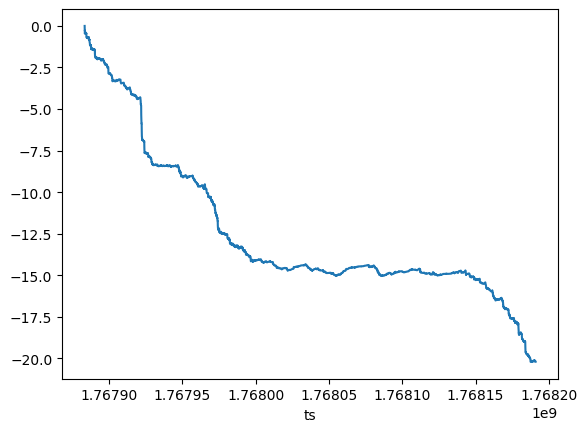

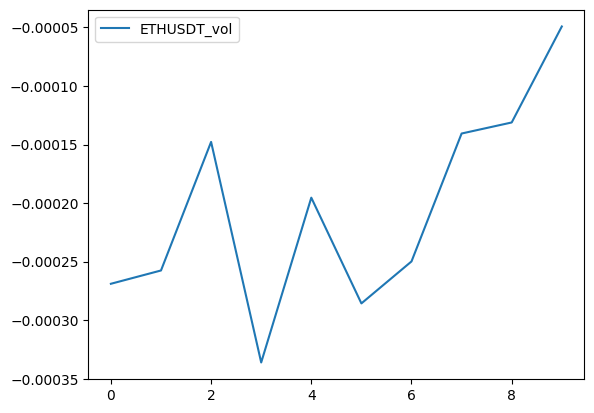

处理 FILUSDT, 读取文件: /home/u171/mth_pub/order_data/FILUSDT_orders.csv
开仓持有时间均值: 68.31秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 474.13秒
平均PnL: 0.000007

总记录数: 156440, 总体平均PnL: 0.000007


count    156440.000000
mean        536.381872
std         820.735713
min           5.000000
25%         116.000000
50%         231.000000
75%         583.000000
max        8540.000000
dtype: float64

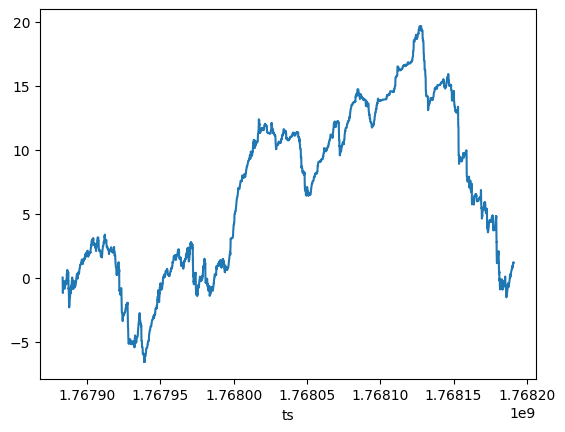

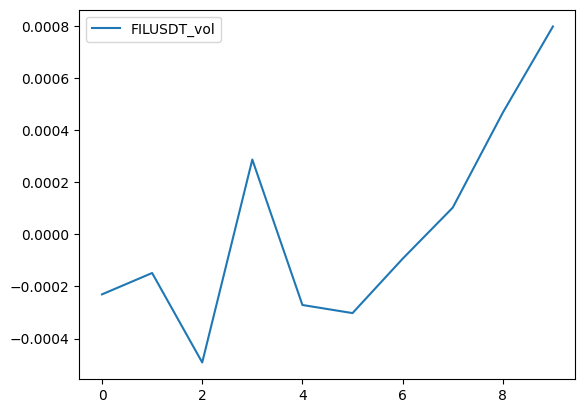

处理 HBARUSDT, 读取文件: /home/u171/mth_pub/order_data/HBARUSDT_orders.csv
开仓持有时间均值: 56.10秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 100.40秒
平均PnL: -0.000380

总记录数: 246672, 总体平均PnL: -0.000380


count    246672.000000
mean        158.112704
std         126.497725
min           5.000000
25%          78.000000
50%         129.000000
75%         194.000000
max        1668.000000
dtype: float64

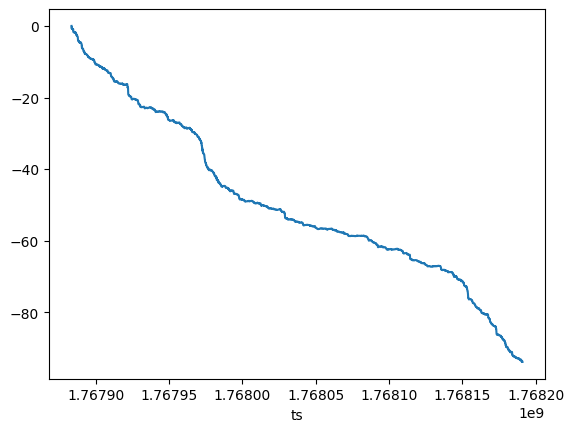

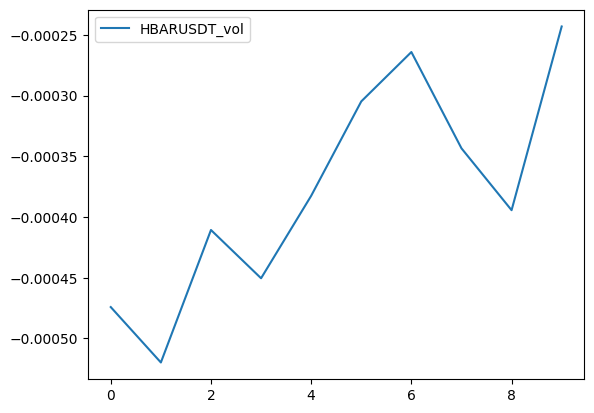

处理 LINKUSDT, 读取文件: /home/u171/mth_pub/order_data/LINKUSDT_orders.csv
开仓持有时间均值: 56.62秒
Range列表: [2.0, 4.0, 8.0, 6.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 121.36秒
平均PnL: -0.000278

总记录数: 194506, 总体平均PnL: -0.000278


count    194506.000000
mean        177.707402
std         163.454167
min           5.000000
25%          79.000000
50%         131.000000
75%         215.000000
max        2094.000000
dtype: float64

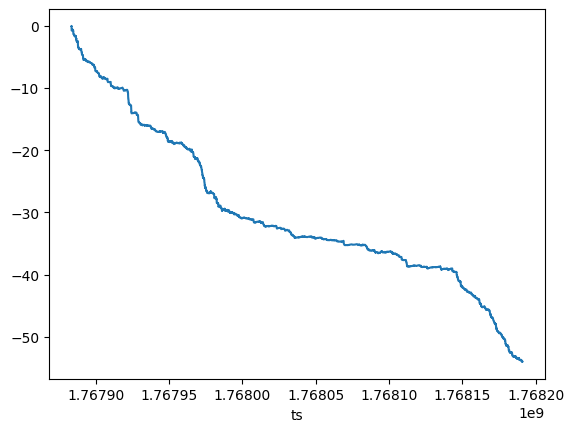

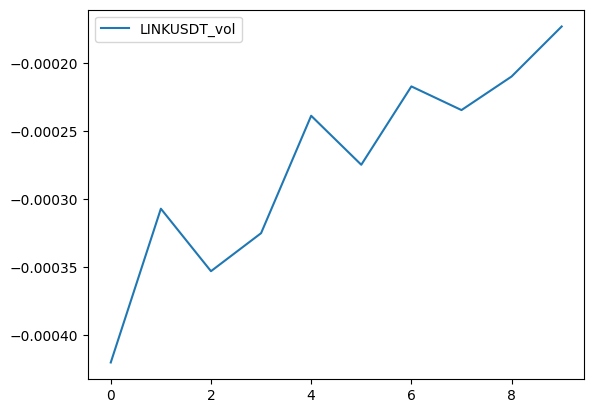

处理 LTCUSDT, 读取文件: /home/u171/mth_pub/order_data/LTCUSDT_orders.csv
开仓持有时间均值: 58.04秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 244.48秒
平均PnL: -0.000207

总记录数: 140536, 总体平均PnL: -0.000207


count    140536.000000
mean        303.262075
std         391.102221
min           5.000000
25%          98.000000
50%         170.000000
75%         342.000000
max        4408.000000
dtype: float64

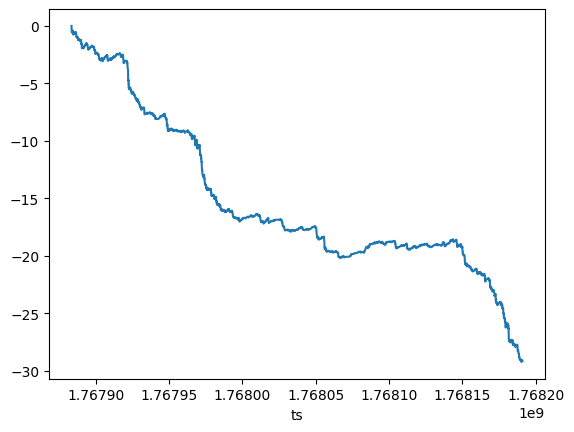

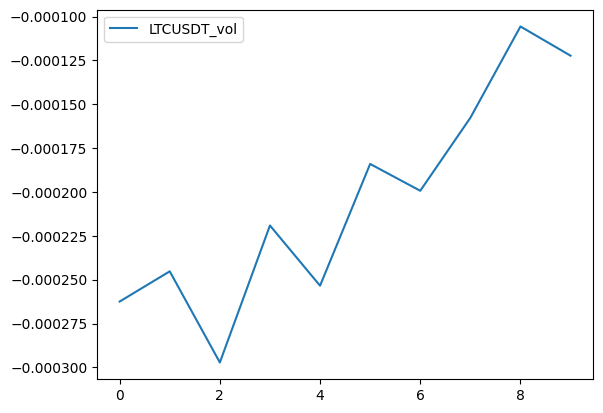

处理 SOLUSDT, 读取文件: /home/u171/mth_pub/order_data/SOLUSDT_orders.csv
开仓持有时间均值: 53.38秒
Range列表: [2.0, 8.0, 6.0, 4.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 191.91秒
平均PnL: -0.000293

总记录数: 182414, 总体平均PnL: -0.000293


count    182414.000000
mean        244.239050
std         340.270791
min           5.000000
25%          81.000000
50%         139.000000
75%         260.000000
max        5418.000000
dtype: float64

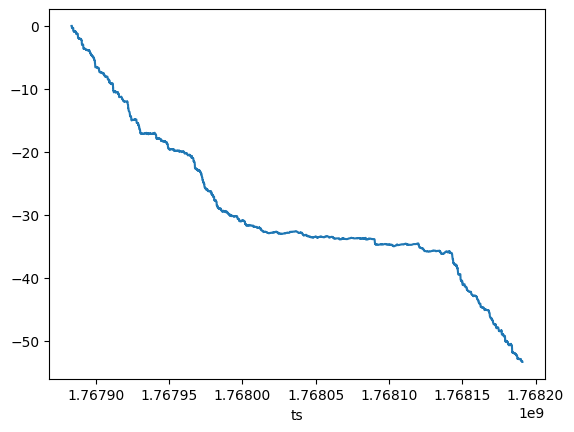

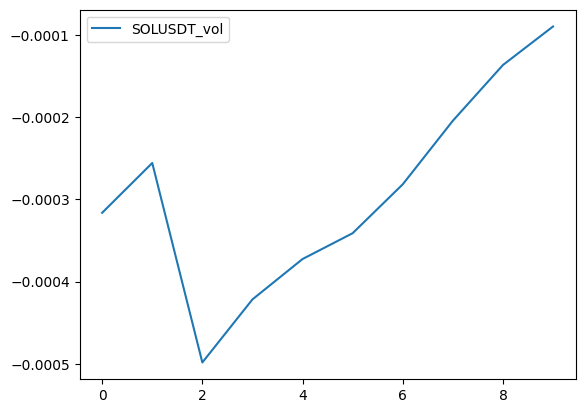

处理 TONUSDT, 读取文件: /home/u171/mth_pub/order_data/TONUSDT_orders.csv
开仓持有时间均值: 69.21秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 105.06秒
平均PnL: -0.000211

总记录数: 146984, 总体平均PnL: -0.000211


count    146984.000000
mean        173.031643
std         138.032308
min           5.000000
25%          90.000000
50%         136.000000
75%         209.000000
max        1729.000000
dtype: float64

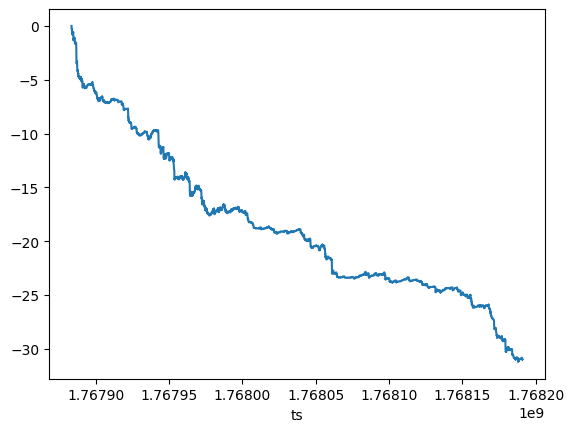

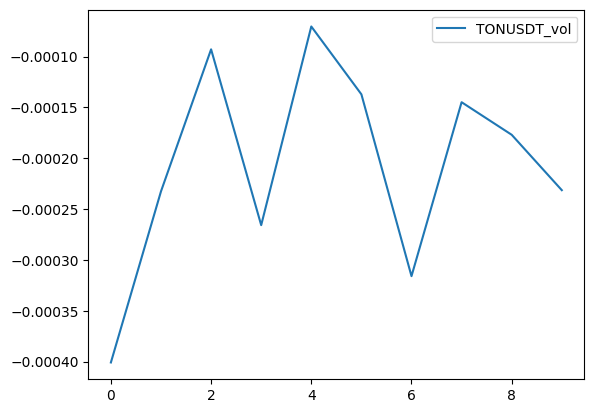

处理 TRXUSDT, 读取文件: /home/u171/mth_pub/order_data/TRXUSDT_orders.csv
开仓持有时间均值: 63.84秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 672.38秒
平均PnL: -0.000332

总记录数: 52066, 总体平均PnL: -0.000332


count    52066.000000
mean       737.615277
std        914.480116
min          5.000000
25%        182.000000
50%        419.000000
75%        921.000000
max       9732.000000
dtype: float64

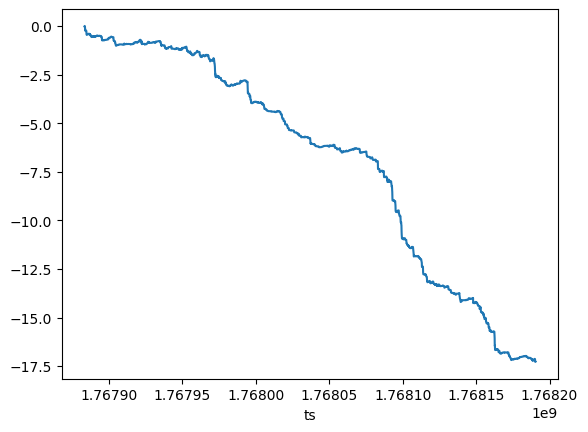

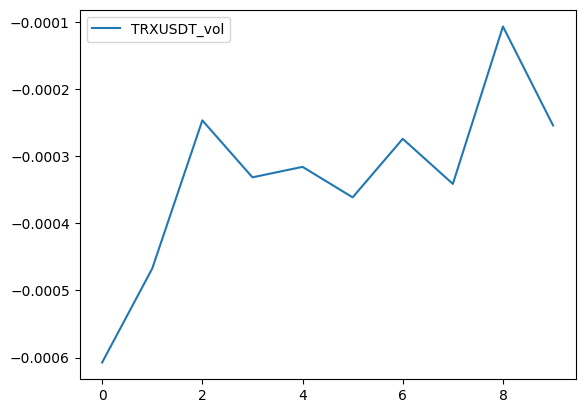

处理 WLDUSDT, 读取文件: /home/u171/mth_pub/order_data/WLDUSDT_orders.csv
开仓持有时间均值: 64.72秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 73.85秒
平均PnL: -0.000340

总记录数: 127074, 总体平均PnL: -0.000340


count    127074.000000
mean        136.714749
std         107.338612
min           5.000000
25%          73.000000
50%         114.000000
75%         164.000000
max        1861.000000
dtype: float64

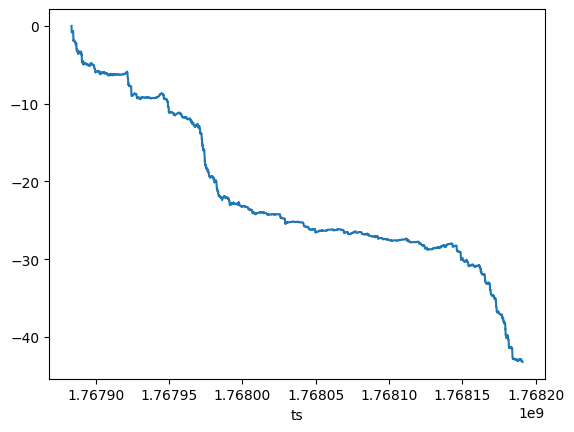

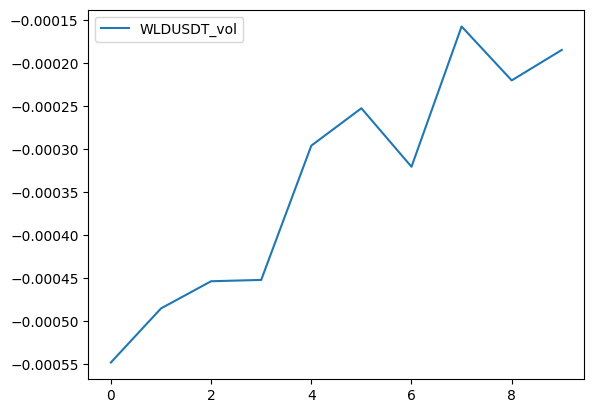

处理 XLMUSDT, 读取文件: /home/u171/mth_pub/order_data/XLMUSDT_orders.csv
开仓持有时间均值: 59.68秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 99.27秒
平均PnL: -0.000401

总记录数: 170476, 总体平均PnL: -0.000401


count    170476.000000
mean        161.384248
std         127.315013
min           5.000000
25%          82.000000
50%         131.000000
75%         198.000000
max        1544.000000
dtype: float64

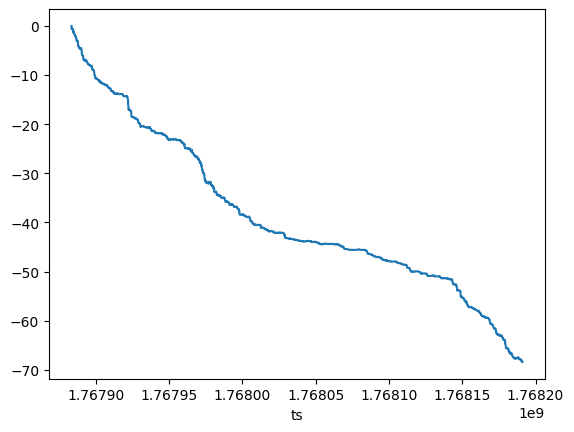

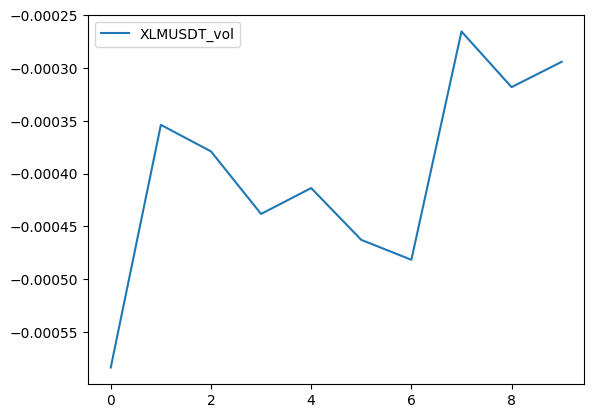

处理 XRPUSDT, 读取文件: /home/u171/mth_pub/order_data/XRPUSDT_orders.csv
开仓持有时间均值: 54.65秒
Range列表: [2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0]
平仓持有时间均值: 167.88秒
平均PnL: -0.000270

总记录数: 176849, 总体平均PnL: -0.000270


count    176849.000000
mean        221.544572
std         272.659282
min           5.000000
25%          81.000000
50%         138.000000
75%         247.000000
max        3889.000000
dtype: float64

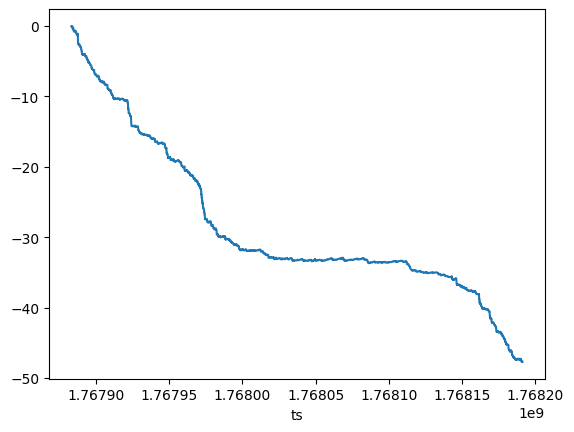

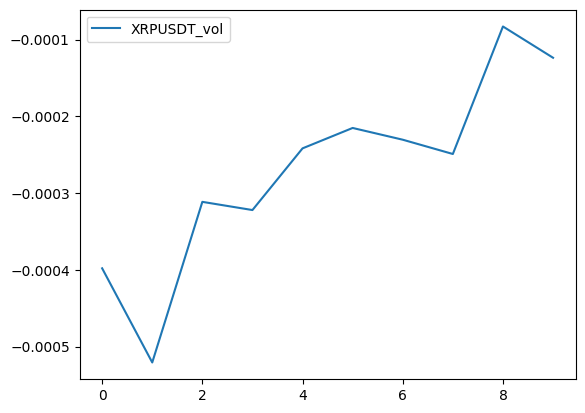

In [2]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt 

pd.options.mode.chained_assignment = None 

# 配置路径 
root_path = '/home/u171/mth_pub/order_data' 
outputpath = '/home/u171/mth_pub/matched_orders' 
os.makedirs(outputpath, exist_ok=True) 

# 币种列表 - 从你的目录结构中提取 
symbols = sorted([
    "AAVEUSDT", "ADAUSDT", "ARBUSDT", "ATOMUSDT", "AVAXUSDT", 
    "BCHUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "DOTUSDT", 
    "ETCUSDT", "ETHUSDT", "FILUSDT", "HBARUSDT", "LINKUSDT", 
    "LTCUSDT", "SOLUSDT", "TONUSDT", "TRXUSDT", "WLDUSDT", 
    "XLMUSDT", "XRPUSDT"
])

mstr = "1m"
fee = 0.0001

for symbol in symbols:
    output_file = os.path.join(outputpath, f"{symbol}_{mstr}.h5")
    
    # if os.path.exists(output_file):
    #     print(f'文件 {output_file} 已存在,跳过') 
    #     continue
    
    order_file_path = os.path.join(root_path, f"{symbol}_orders.csv")
    
    if not os.path.exists(order_file_path):
        print(f"文件不存在: {order_file_path},跳过")
        continue
    
    print(f"处理 {symbol}, 读取文件: {order_file_path}")
    
    try:
        ns = pd.read_csv(order_file_path, header=None) 
        # display(ns.head(2))
        ns.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen", "fkey", "bid1", "ask1"]
        ns.sort_values('uts', inplace=True)
        
    except (pd.errors.EmptyDataError, FileNotFoundError) as e:
        print(f"警告: 文件 {order_file_path} 读取失败: {e}, 跳过")
        continue
    
    if len(ns) == 0:
        print(f"警告: {symbol} 数据为空,跳过")
        continue
    
    # 时间戳转换 
    ns["cts"] = (ns["cts"] / 1000).astype("int") 
    ns["uts"] = (ns["uts"] / 1000).astype("int") 
    
    # ===== 开仓订单处理 =====
    ns_open = ns[(ns["oid"].str.startswith("o")) & (ns["sid"] == 0)] 
    
    if len(ns_open) == 0:
        print(f"警告: {symbol} 没有开仓订单,跳过")
        continue
    
    ns_open["holding"] = ns_open['uts'] - ns_open['cts'] 
    # display(ns_open["holding"].describe())
    print(f'开仓持有时间均值: {ns_open["holding"].mean():.2f}秒') 
    
    # 提取range信息
    ns_open["range"] = (ns_open["oid"].str.split("_", expand=True)[2].astype("float") * 10000).round(0)
    ranges = ns_open["range"].drop_duplicates().tolist()
    print(f'Range列表: {ranges}') 
    
    # 聚合开仓订单信息 
    prices = ns_open.groupby("oid").last().reset_index()[
        ["cts", "uts", 'holding', "oid", "price", "fkey", "side", "range", 'tlen']
    ]
    prices["open_uts"] = prices["uts"]
    prices["tlen"] = prices["tlen"] * prices["price"] 
    
    famount = ns_open.groupby("oid")["famount"].sum().reset_index() 
    ns_open_m = pd.merge(prices, famount, on=["oid"], how="left") 
    
    # ===== 平仓订单处理 =====
    ns_close = ns[(ns["oid"].str.startswith("c")) & (ns["sid"] == 1)].sort_values('uts')
    
    if len(ns_close) == 0:
        print(f"警告: {symbol} 没有平仓订单,跳过")
        continue
    
    ns_close["fkey"] = ns_close["fkey"].str.split("_", expand=True)[2]
    ns_close["crange"] = (ns_close["oid"].str.split("_", expand=True)[5].astype("float") * 10000).round(0)
    
    # 平仓时间和次数统计
    fts = ns_close.groupby("fkey")[["uts", "crange"]].last().reset_index()
    count = ns_close.groupby("fkey")[["uts"]].count().reset_index()
    count.columns = ["fkey", "close_count"]
    fts = pd.merge(fts, count, left_on='fkey', right_on='fkey', how='inner')
    fts["uts"] = fts["uts"].astype("int")
    fts.columns = ["fkey", "fts", "crange", "close_count"]
    
    # 平仓成交量和价格
    famounts = ns_close.groupby("fkey")["famount"].sum().reset_index()
    famounts.columns = ["fkey", "camount"]
    
    ns_close["pa"] = ns_close["famount"] * ns_close["price"]
    pas = ns_close.groupby("fkey")["pa"].sum().reset_index()
    pas = pd.merge(pas, fts, on=["fkey"], how="left")
    nm = pd.merge(pas, famounts, on=["fkey"], how="left")
    nm["cprice"] = nm["pa"] / nm["camount"]
    
    # ===== 合并开仓和平仓数据 =====
    nms = pd.merge(ns_open_m, nm, on="fkey", how="left").dropna()
    
    if len(nms) == 0:
        print(f"警告: {symbol} 匹配后数据为空,跳过")
        continue
    
    # ===== 计算PnL =====
    nms.loc[nms["side"] == "buy", "pnlu"] = (
        (nms[nms["side"] == "buy"]["cprice"] - nms[nms["side"] == "buy"]["price"]) / 
        nms[nms["side"] == "buy"]["price"]
    )
    nms.loc[nms["side"] == "sell", "pnlu"] = (
        (nms[nms["side"] == "sell"]["price"] - nms[nms["side"] == "sell"]["cprice"]) / 
        nms[nms["side"] == "sell"]["price"]
    )
    nms["pnlu_wfee"] = nms["pnlu"] - 2 * fee
    
    nms["fts"] = nms["fts"].astype("int")
    nms["holding_close"] = nms['fts'] - nms['open_uts']
    
    print(f'平仓持有时间均值: {nms["holding_close"].mean():.2f}秒')
    print(f'平均PnL: {nms["pnlu"].mean():.6f}')
    
    # ===== 整理输出列 =====
    nms = nms[[
        'cts', 'open_uts', 'fts', 'holding', 'holding_close', 'close_count',
        'price', 'cprice', 'camount', 'side', 'range', 'crange', 'tlen',
        'pnlu', 'pnlu_wfee'
    ]] 
    nms.sort_values('cts', inplace=True) 
    # display(nms.head(50)) 
    
    # ===== 按range和crange分组统计 =====
    # print("\n按range和crange分组的平均PnL:") 
    # print(nms.groupby(['range', 'crange'])['pnlu'].mean())
    print(f"\n总记录数: {len(nms)}, 总体平均PnL: {nms.pnlu.mean():.6f}")


    order_df = nms.rename(columns={'cts': 'ts'}).set_index('ts')[['pnlu', 'tlen', 'holding', 'holding_close', 'range', 'crange', 'side']]
    # order_df = order_df[((order_df['holding'] + order_df['holding_close']) < 600)] 
    display((order_df['holding'] + order_df['holding_close']).describe()) 

    factor_df2 = (order_df.groupby('ts')[['pnlu']].count() * order_df.groupby('ts')[['pnlu']].mean())
    ts_df = pd.DataFrame({'ts':list(range(factor_df2.index.min(), factor_df2.index.max()+1, 5))}).set_index('ts')
    factor_df2 = pd.merge(ts_df, factor_df2, left_index=True, right_index=True, how='left')
    factor_df2['ylabel'] = factor_df2['pnlu'].rolling(720,min_periods=10).mean().shift(120)
    # factor_df2['ylabel'].plot()
    # plt.show()
    factor_df2 = factor_df2[['ylabel']].ffill() 
    # display(factor_df2) 

    order_df['pnlu'].cumsum().plot(label=f'{symbol}_cum_pnl')
    plt.show()


    final_df1 = pd.merge(order_df, factor_df2, left_index=True, right_index=True, how='left') 
    
    plt.plot(final_df1.groupby(pd.qcut(final_df1['ylabel'], 10, labels=False, duplicates='drop'))['pnlu'].mean(), label=f'{symbol}_vol')
    plt.legend() 
    plt.show() 

    # break

    
#     # ===== 绘制累积收益曲线 =====
#     try:
#         plt.figure(figsize=(10, 4))
#         last_df = nms[['cts', 'pnlu']].sort_values('cts').set_index('cts')
#         last_df.index = pd.to_datetime(last_df.index, unit='s')
#         (last_df['pnlu']).cumsum().plot(label=f'{symbol}_cumulative_pnl')
#         plt.title(f'{symbol} Cumulative PnL')
#         plt.xlabel('Time')
#         plt.ylabel('Cumulative PnL')
#         plt.legend()
#         plt.grid(alpha=0.3)
#         plt.tight_layout()
#         # plt.savefig(os.path.join(outputpath, f"{symbol}_pnl_curve.png"), dpi=100)
#         # plt.close()
#         # print(f"图表已保存: {symbol}_pnl_curve.png")
#     except Exception as e:
#         print(f"绘图失败: {e}")
    
#     # ===== 保存结果 =====
#     nms.to_hdf(output_file, key="df", mode='w')
#     print(f"数据已保存: {output_file}\n")
#     print("=" * 80)

# print("\n所有处理完成!") 

In [4]:
86400 / 5 / 5

3456.0

In [ ]:
# import pandas as pd 
# import numpy as np
# import matplotlib.pyplot as plt 

# outputpath = "Z:\homes\guoqi\morder\match_sample_month24062504_twoexchange_sid01_closets0s_closerb0003_sample1s" 
# os.makedirs(outputpath, exist_ok=True) 
# # root_path = 'Z://market_data//rust//hout' 
# root_path = 'G://nas//NLshare//market_data//rust//hout' # 'G://NLshare//market_data//rust//hout' 
# symbols = ["APTUSDT","ARBUSDT","AXSUSDT","DOGEUSDT","OPUSDT","DOTUSDT","ENSUSDT","SANDUSDT","SOLUSDT"] # 
# # symbols = "SOLUSDT,ARBUSDT,DOGEUSDT,DOTUSDT".split(',') 
# mstr = "1m" 
# lasts = [60] 
# fee = -0.00005 


# order_list = [] 
# for symbol in symbols: 
#     for month in ['202406','202407','202408','202409','202410','202411','202412','202501','202502','202503','202504']: # '202406','202407','202408','202409','202410','202411','202412','202501','202502','202503','202504'
#         if os.path.exists(os.path.join(outputpath, f"{symbol}_{month}_{mstr}.h5")): 
#             print(f'文件 {os.path.join(outputpath, f"{symbol}_{month}_{mstr}.h5")} 已存在，跳过')
#             continue 
#         sall = None 
#         for last in lasts: 
#             order_file_list = [] 
#             for path in norder_paths[last]: 
#                 dir_path = os.path.join(root_path, path) 
#                 order_file_list.append(dir_path)
            
#             month_file_list = [file for file in order_file_list if (file.split('_')[9][:6] == month)]
#             print(symbol, last, len(month_file_list), month) 
                

#             for file in month_file_list:
#                 file_path = os.path.join(file, f"{symbol}_orders.csv") 
#                 if not os.path.exists(file_path): 
#                     print(f"File does not exist: {file_path}") 
#                 print(file_path) 

#                 # open order 
#                 try:
#                     ns = pd.read_csv(file_path, header=None) 
#                     ns.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen","fkey","bid1","ask1"] 
#                     # ns.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen_na","fkey","bid1","ask1","tlen"] 
#                     ns.sort_values('uts',inplace=True) 
#                 except (pd.errors.EmptyDataError, FileNotFoundError):
#                     print(f"警告: 文件 {file_path} 为空或不存在，跳过") 

#                 ns["cts"] = (ns["cts"] / 1000).astype("int") 
#                 ns["uts"] = (ns["uts"] / 1000).astype("int") 

#                 ns_open = ns[(ns["oid"].str.startswith("o")) & (ns["sid"] == 0)] 
#                 ns_open["holding"] = ns_open['uts'] - ns_open['cts'] 
#                 print('open_holding_time:', ns_open["holding"].mean()) 
#                 ns_open["range"] = (ns_open["oid"].str.split("_", expand=True)[2].astype("float") * 10000).round(0) #.astype("int") 
#                 ranges = ns_open["range"].drop_duplicates().tolist() 
#                 print(ranges) 
#                 # print(ns_open.status.unique()) 
                
#                 prices = ns_open.groupby("oid").last().reset_index()[["cts", "uts", 'holding', "oid", "price", "fkey", "side", "range",'tlen']] 
#                 # tlen = ns_open[ns_open['status']=='open'].groupby("oid").first().reset_index()[[,"oid",]] 
#                 # prices = pd.merge(prices, tlen, on=["oid"], how="left") 
#                 prices["open_uts"] = prices["uts"] 
#                 prices["tlen"] = prices["tlen"] * prices["price"] 
#                 famount = ns_open.groupby("oid")["famount"].sum().reset_index() 
#                 ns_open_m = pd.merge(prices, famount, on=["oid"], how="left") 

#                 # close order 
#                 ns_close = ns[(ns["oid"].str.startswith("c")) & (ns["sid"] == 1)].sort_values('uts') 
#                 ns_close["fkey"] = ns_close["fkey"].str.split("_", expand=True)[2] 
#                 ns_close["crange"] = (ns_close["oid"].str.split("_", expand=True)[5].astype("float") * 10000).round(0) # .astype("int") 

#                 fts = ns_close.groupby("fkey")[["uts", "crange"]].last().reset_index() 
#                 count = ns_close.groupby("fkey")[["uts"]].count().reset_index() 
#                 count.columns = ["fkey", "close_count"] 
#                 fts = pd.merge(fts, count, left_on='fkey',right_on='fkey',how='inner') 
#                 fts["uts"] = fts["uts"].astype("int") 
#                 fts.columns = ["fkey", "fts", "crange", "close_count"] 


#                 famounts = ns_close.groupby("fkey")["famount"].sum().reset_index() 
#                 famounts.columns = ["fkey", "camount"] 
#                 ns_close["pa"] = ns_close["famount"] * ns_close["price"] 
#                 pas = ns_close.groupby("fkey")["pa"].sum().reset_index() 
#                 pas = pd.merge(pas, fts, on=["fkey"], how="left") 
#                 nm = pd.merge(pas, famounts, on=["fkey"], how="left") 
#                 nm["cprice"] = nm["pa"] / nm["camount"] 
#                 # display(nm) 
                
#                 nms = pd.merge(ns_open_m, nm, on="fkey", how="left").dropna() 
#                 # display(nms) 

#                 # display(nms) 
#                 # nms.loc[nms["side"] == "buy", "pnlu"] = (nms[nms["side"] == "buy"]["cprice"] - nms[nms["side"] == "buy"]["price"])*nms[nms["side"] == "buy"]["famount"]
#                 # nms.loc[nms["side"] == "sell", "pnlu"] = (nms[nms["side"] == "sell"]["price"] - nms[nms["side"] == "sell"]["cprice"])*nms[nms["side"] == "sell"]["famount"]
#                 # nms["pnlu_wfee"] = nms["pnlu"] - fee*(nms["famount"] * nms["price"]) - fee*(nms["famount"] * nms["price"])

#                 nms.loc[nms["side"] == "buy", "pnlu"] = (nms[nms["side"] == "buy"]["cprice"] - nms[nms["side"] == "buy"]["price"]) / nms[nms["side"] == "buy"]["cprice"]
#                 nms.loc[nms["side"] == "sell", "pnlu"] = (nms[nms["side"] == "sell"]["price"] - nms[nms["side"] == "sell"]["cprice"])/ nms[nms["side"] == "sell"]["price"]
#                 nms["pnlu_wfee"] = nms["pnlu"] - 2*fee 

#                 nms["last"] = last 
#                 nms["fts"] = nms["fts"].astype("int") 
#                 nms["holding_close"] = nms['fts'] - nms['open_uts'] 
#                 print('clse_holding_time:', nms["holding_close"].mean(), 'pnlu_mean', nms["pnlu"].mean()) 

#                 nms = nms[['cts', 'open_uts', 'fts', 'holding', 'holding_close', 'close_count', 'price', 'cprice', 'camount', 'side', 'range', 'crange', 'tlen', 'pnlu', 'pnlu_wfee', 'last']]
#                 sall = nms if sall is None else pd.concat([sall, nms]) 
#                 sall.sort_values('cts', inplace=True) 

#         # order_list.append(sall) 
#         display(sall.groupby(['range', 'crange'])['pnlu'].mean()) 
#         print(len(sall), sall.pnlu.mean()) 
#         # display(sall.head()) 
        
#         # sall.groupby(pd.qcut(sall["tlen"], 10, duplicates="drop"))['pnlu'].mean().plot() 
#         # plt.show() 
#         threshold =  0.8 
        
#         plt.figure(figsize=(10, 4)) # [sall['range'] > 8.0] #  & (sall['range'] > 8.0) 
#         last_df = sall[['cts', 'pnlu']].sort_values('cts').set_index('cts') # & (merged[f"range"] > 0.0) & (merged[f"crange"] > 0.0) , 'pnlu_wfee' 
#         last_df.index = pd.to_datetime(last_df.index, unit='s') 
#         (last_df['pnlu'] + 0.0001).cumsum().plot(label=f'{symbol}_select') 
#         plt.legend() 
#         plt.show() 
        
#         sall.to_hdf(outputpath+"//"+f"{symbol}_{month}"+"_"+mstr+".h5", key="df", mode='w') 
